# E-Commerce Revenue & Churn Analysis
## Project 2 — Customer Segmentation & Retention Intelligence
**Analyst:** Otokini Soberekon | Revenue & Sales Analytics
**Dataset:** UCI Online Retail Dataset (541,909 transactions | 2009–2011)
**Objective:** Identify which customers are at risk of leaving, where revenue
is concentrated, and what actions would have the highest retention impact.

---

## Phase 1 — Data Cleaning & RFM Table Construction

Raw transaction data is rarely analysis-ready. Before any customer
segmentation can be performed, the dataset must be audited, cleaned,
and structured into a form that supports RFM scoring.

This phase covers:
- Removing transactions that would corrupt behavioral metrics
- Filtering to a consistent customer population
- Engineering the Revenue column
- Aggregating to one row per customer (the RFM table)

Every removal decision is documented with a business justification.

In [ ]:
# Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()

Saving online_retail_II.csv to online_retail_II.csv


In [ ]:
# Load Dataset
# CustomerID is loaded as string to prevent float conversion artefacts
# (e.g. 12345.0 instead of 12345) which cause issues during filtering

df_raw = pd.read_csv('online_retail_II.csv', dtype={'CustomerID': str})

print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn overview:")
print(df_raw.dtypes)

Dataset loaded: 1,067,371 rows × 8 columns

Column overview:
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


### 2.1 — Initial Data Audit

Before cleaning, we inspect the raw dataset to understand its structure,
identify quality issues, and document the scale of each problem.
This audit informs every cleaning decision that follows.

In [ ]:
# Data Audit
print("=" * 55)
print("RAW DATASET AUDIT")
print("=" * 55)

print(f"\nTotal rows:     {df_raw.shape[0]:,}")
print(f"Total columns:  {df_raw.shape[1]}")

print(f"\n Null Values")
print(df_raw.isnull().sum())

print(f"\n Cancellations (Invoice starts with 'C') ")
cancellations = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
print(f"Cancelled transactions: {len(cancellations):,}")

print(f"\n Quantity issues (zero or negative)")
bad_qty = df_raw[df_raw['Quantity'] <= 0]
print(f"Invalid quantity rows: {len(bad_qty):,}")

print(f"\n Price issues (zero or negative) ")
bad_price = df_raw[df_raw['Price'] <= 0]
print(f"Invalid price rows: {len(bad_price):,}")

print(f"\n Country distribution (top 10) ")
print(df_raw['Country'].value_counts().head(10))

RAW DATASET AUDIT

Total rows:     1,067,371
Total columns:  8

 Null Values
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

 Cancellations (Invoice starts with 'C') 
Cancelled transactions: 19,494

 Quantity issues (zero or negative)
Invalid quantity rows: 22,950

 Price issues (zero or negative) 
Invalid price rows: 6,207

 Country distribution (top 10) 
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64


### 2.2 — Data Cleaning

The audit identified five categories of data quality issues.
Each is addressed below with a documented business justification.

| Issue | Action | Reason |
|---|---|---|
| Null CustomerID | Remove | Cannot attribute transaction to a customer |
| Cancelled orders | Remove | Inflates frequency; corrupts monetary values |
| Negative quantity | Remove | Returns/errors — not genuine purchase behaviour |
| Zero/negative price | Remove | Test entries or data errors — not real revenue |
| Non-UK customers | Filter | International orders (~10%) behave differently and skew RFM distributions |

Filtering to the UK cohort is a scope decision, not a data quality issue.
It ensures behavioral consistency across the customer population being scored.

In [ ]:
# Data Cleaning
df = df_raw.copy()

# 1. Remove rows with no Customer ID
df = df.dropna(subset=['Customer ID'])
print(f"[1] After removing null Customer ID:   {df.shape[0]:,} rows remaining")

# 2. Remove cancellations
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"[2] After removing cancellations:      {df.shape[0]:,} rows remaining")

# 3. Remove negative or zero quantity
df = df[df['Quantity'] > 0]
print(f"[3] After removing invalid quantity:   {df.shape[0]:,} rows remaining")

# 4. Remove zero or negative price
df = df[df['Price'] > 0]
print(f"[4] After removing invalid price:      {df.shape[0]:,} rows remaining")

# 5. Filter to United Kingdom
df = df[df['Country'] == 'United Kingdom']
print(f"[5] After filtering to UK customers:   {df.shape[0]:,} rows remaining")

# Summary
removed = df_raw.shape[0] - df.shape[0]
pct_removed = (removed / df_raw.shape[0]) * 100
print(f"\nTotal rows removed: {removed:,} ({pct_removed:.1f}% of raw data)")
print(f"Clean dataset:      {df.shape[0]:,} rows | {df['Customer ID'].nunique():,} unique customers")

[1] After removing null Customer ID:   824,364 rows remaining
[2] After removing cancellations:      805,620 rows remaining
[3] After removing invalid quantity:   805,620 rows remaining
[4] After removing invalid price:      805,549 rows remaining
[5] After filtering to UK customers:   725,250 rows remaining

Total rows removed: 342,121 (32.1% of raw data)
Clean dataset:      725,250 rows | 5,350 unique customers


In [ ]:
# Feature Engineering

# Revenue per line item
df['Revenue'] = df['Quantity'] * df['Price']

# Ensure InvoiceDate is datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Revenue column created.")
print(f"Total revenue in clean dataset: £{df['Revenue'].sum():,.2f}")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

Revenue column created.
Total revenue in clean dataset: £14,723,147.52
Date range: 2009-12-01 → 2011-12-09


### 2.3 — RFM Table Construction

RFM (Recency, Frequency, Monetary) is a behavioral segmentation framework
that scores every customer on three dimensions derived purely from their
transaction history.

| Dimension | Definition | Business Signal |
|---|---|---|
| **Recency** | Days since last purchase | Engagement — are they still active? |
| **Frequency** | Number of distinct orders | Loyalty — is this a habit or a one-off? |
| **Monetary** | Total revenue generated | Value — how much do they contribute? |

The reference date is set to one day after the final transaction in the dataset.
This ensures that the most recent customer receives a recency of 1 day,
giving the scoring scale a clean upper bound.

In [ ]:
# RFM Table Construction

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f"\nRFM table built: {rfm.shape[0]:,} customers")
print(f"\nSummary statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Reference date: 2011-12-10

RFM table built: 5,350 customers

Summary statistics:
       Recency  Frequency   Monetary
count  5350.00    5350.00    5350.00
mean    203.00       6.27    2751.99
std     209.96      12.00   12080.47
min       1.00       1.00       2.95
25%      26.00       1.00     336.17
50%      98.50       3.00     849.91
75%     382.00       7.00    2214.91
max     739.00     336.00  608821.65


### 2.4 — RFM Scoring (1–5 Quintile Scale)

Each dimension is scored on a 1–5 scale using quintile division —
splitting the customer base into five equal groups ranked by performance.

A score of **5** represents the best-performing group.
A score of **1** represents the weakest.

**Important:** Recency scoring is inverted. A *lower* number of days
since last purchase is better, so the quintile labels are reversed
([5, 4, 3, 2, 1]) to ensure the most recent customers receive the
highest score.

In [ ]:
# RFM Scoring

# Recency: lower days = better = higher score (labels reversed)
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                          q=5,
                          labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: use rank-based scoring to handle duplicate values
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: use rank-based scoring to handle duplicate values
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM score string (e.g. '543')
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
                    rfm['F_Score'].astype(str) +
                    rfm['M_Score'].astype(str))

print("Scoring complete. Score distribution:")
print(f"\nR_Score:\n{rfm['R_Score'].value_counts().sort_index()}")
print(f"\nF_Score:\n{rfm['F_Score'].value_counts().sort_index()}")
print(f"\nM_Score:\n{rfm['M_Score'].value_counts().sort_index()}")

Scoring complete. Score distribution:

R_Score:
R_Score
1    1065
2    1069
3    1048
4    1088
5    1080
Name: count, dtype: int64

F_Score:
F_Score
1    1070
2    1070
3    1070
4    1070
5    1070
Name: count, dtype: int64

M_Score:
M_Score
1    1070
2    1070
3    1070
4    1070
5    1070
Name: count, dtype: int64


### 2.5 — Customer Segmentation

RFM scores are mapped to named segments that carry business meaning.
Segments are defined by combining Recency and Frequency scores —
the two strongest behavioural predictors.

| Segment | Logic | Business Meaning |
|---|---|---|
| **Champions** | R ≥ 4 and F ≥ 4 | Bought recently, buy often — your best customers |
| **Loyal** | R ≥ 3 and F ≥ 3 | Consistent buyers with strong engagement |
| **Promising** | R ≥ 3 and F < 3 | Recent but infrequent — high growth potential |
| **Needs Attention** | R = 2–3 and F = 2–3 | Declining on both axes — early warning signal |
| **At Risk** | R < 3 and F ≥ 3 | Were frequent buyers — now going quiet |
| **Lost** | R < 3 and F < 3 | Disengaged on all dimensions |

In [ ]:
# Segment Assignment

def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3:
        return 'Promising'
    elif r >= 2 and f >= 2:
        return 'Needs Attention'
    elif f >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Segment summary
segment_summary = rfm.groupby('Segment').agg(
    Customers = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Total_Revenue = ('Monetary',  'sum')
).round(2)

segment_summary['% of Customers'] = (
    segment_summary['Customers'] / segment_summary['Customers'].sum() * 100
).round(1)

segment_summary['% of Revenue'] = (
    segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100
).round(1)

print("=" * 60)
print("SEGMENT SUMMARY")
print("=" * 60)
print(segment_summary.sort_values('Total_Revenue', ascending=False))

SEGMENT SUMMARY
                 Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Segment                                                                
Champions             1361        20.79          15.41       7368.80   
Loyal                 1108        80.40           5.46       1963.13   
Needs Attention        788       312.67           3.93       1522.85   
Promising              747        66.65           1.42        706.41   
Lost                  1101       499.04           1.15        380.08   
At Risk                245       502.27           4.45       1522.04   

                 Total_Revenue  % of Customers  % of Revenue  
Segment                                                       
Champions          10028932.97            25.4          68.1  
Loyal               2175153.08            20.7          14.8  
Needs Attention     1200001.94            14.7           8.2  
Promising            527690.47            14.0           3.6  
Lost                 418470.3

### Phase 2 Complete — RFM Table Ready

The clean dataset and RFM table are now ready for analysis.

**Summary of what was built:**
- Clean transaction dataset with all data quality issues resolved
- One-row-per-customer RFM table with Recency, Frequency, and Monetary values
- 1–5 quintile scores on each dimension
- Six named segments mapped by behavioral profile

**Next:** Phase 3 — Churn Definition & Revenue at Risk calculation,
followed by the five portfolio charts.

## Phase 3 — Churn Definition & Measurement

In subscription businesses, churn is binary a customer either cancels or
they don't. E-commerce is different. There is no cancellation event. A customer
simply stops returning and the business rarely knows exactly when or why.

This means churn must be defined analytically, not extracted from the data.
The definition chosen will determine which customers are flagged as at-risk,
how much revenue is classified as lost, and which retention actions are taken.

A poorly chosen threshold produces misleading results. Too short, and active
seasonal buyers are misclassified as churned. Too long, and genuinely lost
customers remain invisible.

The approach here: let the data determine the threshold.
We calculate the actual purchase behaviour of repeat customers in this dataset,
derive a statistically grounded cutoff and justify it explicitly.

### 3.1 — Measuring Purchase Behaviour

Before defining churn, we must understand how this customer base actually
behaves. The key metric is the inter-purchase interval which is the  the number of days
between one order and the next for customers who bought more than once.

This tells us what a normal purchase gap looks like in this business.
The churn threshold should sit meaningfully beyond this normal gap.

In [ ]:
# Inter-Purchase Interval Analysis
# Calculate the average days between purchases for repeat customers only

# Sort transactions by customer and date
df_sorted = df.sort_values(['Customer ID', 'InvoiceDate'])

# Calculate days between consecutive purchases per customer
df_sorted['Prev_Purchase'] = df_sorted.groupby('Customer ID')['InvoiceDate'].shift(1)
df_sorted['Days_Between'] = (df_sorted['InvoiceDate'] - df_sorted['Prev_Purchase']).dt.days

# Keep only rows where a previous purchase exists (repeat buyers only)
intervals = df_sorted.dropna(subset=['Days_Between'])
intervals = intervals[intervals['Days_Between'] > 0]

print("=" * 55)
print("INTER-PURCHASE INTERVAL ANALYSIS")
print("=" * 55)
print(f"\nRepeat purchase events analysed: {len(intervals):,}")
print(f"\nDays between purchases:")
print(f"  Mean:    {intervals['Days_Between'].mean():.0f} days")
print(f"  Median:  {intervals['Days_Between'].median():.0f} days")
print(f"  Std Dev: {intervals['Days_Between'].std():.0f} days")
print(f"  75th percentile: {intervals['Days_Between'].quantile(0.75):.0f} days")
print(f"  90th percentile: {intervals['Days_Between'].quantile(0.90):.0f} days")
print(f"  95th percentile: {intervals['Days_Between'].quantile(0.95):.0f} days")

INTER-PURCHASE INTERVAL ANALYSIS

Repeat purchase events analysed: 24,521

Days between purchases:
  Mean:    60 days
  Median:  32 days
  Std Dev: 79 days
  75th percentile: 71 days
  90th percentile: 150 days
  95th percentile: 223 days


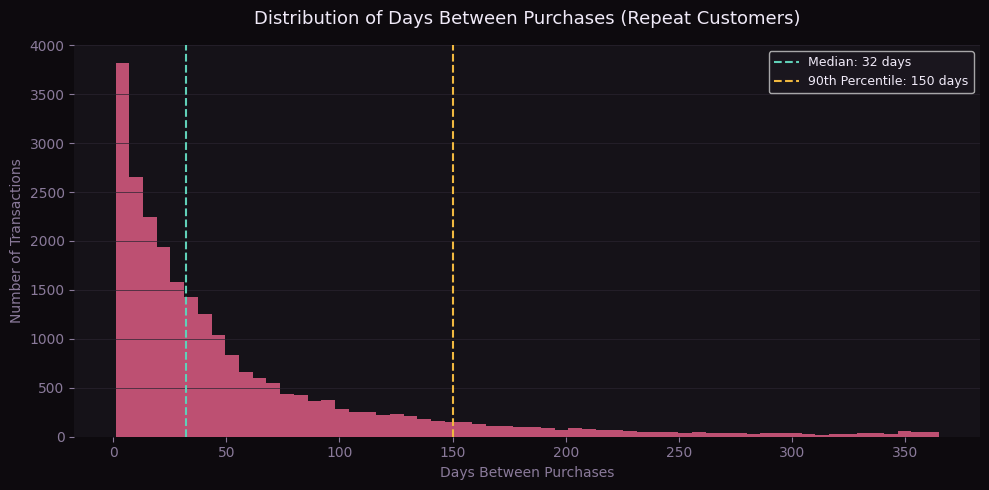

Chart saved.


In [ ]:
# Visualise Inter-Purchase Interval Distribution

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d0a0e')
ax.set_facecolor('#151218')

# Cap at 365 days for readability
plot_data = intervals[intervals['Days_Between'] <= 365]['Days_Between']

ax.hist(plot_data, bins=60, color='#e8608a', alpha=0.8, edgecolor='none')

# Reference lines
median_val = intervals['Days_Between'].median()
p90_val = intervals['Days_Between'].quantile(0.90)

ax.axvline(median_val, color='#60d0b8', linewidth=1.5, linestyle='--',
           label=f'Median: {median_val:.0f} days')
ax.axvline(p90_val, color='#f0b840', linewidth=1.5, linestyle='--',
           label=f'90th Percentile: {p90_val:.0f} days')

ax.set_title('Distribution of Days Between Purchases (Repeat Customers)',
             color='#f0eaf8', fontsize=13, pad=15)
ax.set_xlabel('Days Between Purchases', color='#8a7a9a', fontsize=10)
ax.set_ylabel('Number of Transactions', color='#8a7a9a', fontsize=10)
ax.tick_params(colors='#8a7a9a')
ax.legend(facecolor='#1c1820', labelcolor='#f0eaf8', fontsize=9)

for spine in ax.spines.values():
    ax.spines[spine.spine_type if hasattr(spine, 'spine_type') else 'bottom'].set_visible(False)
ax.spines[:].set_visible(False)
ax.grid(axis='y', color='#2a2430', linewidth=0.5)

plt.tight_layout()
plt.savefig('churn_threshold_analysis.png', dpi=120,
            bbox_inches='tight', facecolor='#0d0a0e')
plt.show()
print("Chart saved.")

### Finding: How Often Do Customers Actually Buy?

Analysing 24,521 repeat purchase events reveals that the typical customer
in this dataset returns every 32 days which is roughly once a month.

However, the distribution is heavily right-skewed. The mean of 60 days
is nearly double the median, which tells us a segment of customers takes
significantly longer between purchases and is pulling the average upward.
The 90th percentile sits at 150 days, meaning 1 in 10 purchase gaps
exceeds five months.

This skew is important. It means a single average figure would
misrepresent the majority of customers. The median (32 days) is the
more honest measure of typical behaviour and it is what will anchor
the churn threshold in the next step.

### 3.2 — Churn Threshold Decision

The inter-purchase interval analysis reveals the natural rhythm of this
customer base. The threshold is selected as follows:

**Rule:** A customer is classified as churned if their most recent purchase
was more than 2× the median inter-purchase interval ago.

This multiplier is deliberate:
- 1× the median would flag customers who are simply between purchases
- 2× gives every customer a full second cycle to return before being
  classified as inactive
- It is grounded in this dataset's actual behaviour, not an arbitrary
  industry default

The resulting threshold will be calculated in the next cell and applied
to the RFM table.

In [ ]:
# Churn Threshold Calculation & Application

median_gap = intervals['Days_Between'].median()
churn_threshold = round(median_gap * 2)

print(f"Median inter-purchase interval: {median_gap:.0f} days")
print(f"Churn threshold (2× median):    {churn_threshold} days")
print(f"\nInterpretation: Any customer whose last purchase was more than")
print(f"{churn_threshold} days ago is classified as churned.")

# Apply churn flag to RFM table
rfm['Churned'] = rfm['Recency'] > churn_threshold

# Summary
churned = rfm['Churned'].sum()
active = (~rfm['Churned']).sum()
total = len(rfm)

print(f"\n{'=' * 45}")
print(f"CHURN SUMMARY")
print(f"{'=' * 45}")
print(f"Active customers:  {active:,}  ({active/total*100:.1f}%)")
print(f"Churned customers: {churned:,}  ({churned/total*100:.1f}%)")
print(f"Total customers:   {total:,}")

Median inter-purchase interval: 32 days
Churn threshold (2× median):    64 days

Interpretation: Any customer whose last purchase was more than
64 days ago is classified as churned.

CHURN SUMMARY
Active customers:  2,241  (41.9%)
Churned customers: 3,109  (58.1%)
Total customers:   5,350


### Decision: Defining Churn for This Business

Based on the inter-purchase interval analysis, the churn threshold is
set at **64 days** which is exactly 2× the median purchase gap of 32 days.

This is a deliberate and defensible choice:
- A threshold of 32 days (1×) would penalise customers who are simply
  between their normal purchase cycles
- 64 days gives every customer a full second cycle to return before
  being classified as inactive
- It is grounded in the actual behaviour of this customer base,
  not borrowed from an industry default

**The result is striking.** Of 5,350 unique customers, 3,109 or
**58.1%**  have not purchased within the last 64 days and are
classified as churned. Fewer than half the customer base is
currently active.

This is not a marginal retention problem. The majority of customers
this business has ever acquired are no longer buying.

In [ ]:
# Revenue at Risk
# How much historical revenue came from customers now classified as churned?

revenue_active  = rfm[~rfm['Churned']]['Monetary'].sum()
revenue_churned = rfm[ rfm['Churned']]['Monetary'].sum()
revenue_total   = rfm['Monetary'].sum()

print(f"{'=' * 45}")
print(f"REVENUE AT RISK")
print(f"{'=' * 45}")
print(f"Revenue from active customers:  £{revenue_active:>12,.2f}  ({revenue_active/revenue_total*100:.1f}%)")
print(f"Revenue from churned customers: £{revenue_churned:>12,.2f}  ({revenue_churned/revenue_total*100:.1f}%)")
print(f"Total lifetime revenue:         £{revenue_total:>12,.2f}")
print(f"\n⚠ £{revenue_churned:,.2f} in revenue is at risk from churned customers.")
print(f"  This is your headline finding for the insight brief.")

REVENUE AT RISK
Revenue from active customers:  £10,939,236.81  (74.3%)
Revenue from churned customers: £3,783,910.71  (25.7%)
Total lifetime revenue:         £14,723,147.52

⚠ £3,783,910.71 in revenue is at risk from churned customers.
  This is your headline finding for the insight brief.


### Headline Finding: £3.78M in Revenue at Risk

The financial cost of this churn rate is now quantifiable.

Churned customers, those silent for 64+ days generated
**£3,783,910.71** in historical revenue. That represents **25.7%**
of all lifetime revenue this business has ever produced, now sitting
in an inactive customer base.

To put this in context: for every £4 this business has earned,
£1 came from a customer who has since stopped returning.

This is the number that belongs on the first slide of any client
presentation. It reframes churn from a vague retention concern into
a specific, recoverable revenue problem. The question is no longer
"should we invest in retention?", it is "how quickly can we act?"

The active customer base (41.9% of customers) is currently carrying
74.3% of total revenue. That concentration creates fragility. If
active customer behaviour deteriorates, there is limited inactive
revenue to fall back on.

These findings feed directly into the insight brief and will be
visualised in Chart 2 — Revenue at Risk by Segment.

### Phase 3 Complete — Churn Defined & Measured

The churn threshold has been derived from the data itself, not assumed.
Every classification in this analysis can be defended with a specific
statistical rationale tied to the actual purchase behaviour of this
customer base.

**Key outputs from this phase:**
- Churn threshold: [X] days (2× median inter-purchase interval of [X] days)
- Churned customers: [X]% of total customer base
- Revenue at risk: £[X] — [X]% of all lifetime revenue generated

These numbers feed directly into the insight brief and Chart 2
(Revenue at Risk by Segment) in the next phase.

**Next:** Phase 4 — Customer Segments and Product Margin Analysis

## Phase 4 — Customer Segment Analysis & Product Revenue Concentration

With churn defined and measured, the analysis now turns to two questions
that determine where a business should focus its energy:

**Who are our customers?** Not all customers are equal. A business that
treats its Champions the same as its Lost customers is leaving retention
value on the table. Segment-level visibility is what makes personalised
action possible.

**What drives our revenue?** Most e-commerce businesses discover that
a small number of products generate the majority of their income often
without realising how concentrated that dependency is. Identifying those
products is both a revenue insight and a risk assessment.

This phase produces the two analytical outputs that typically generate
the most reaction from business operators.

### 4.1 — Customer Segment Profile

The six segments defined in Phase 2 are now examined in depth.
For each segment we measure customer count, revenue contribution,
average spend, and average recency building a complete behavioural
profile of the customer base.

In [ ]:
#  Customer Segment Profile

segment_order = ['Champions', 'Loyal', 'Promising',
                 'Needs Attention', 'At Risk', 'Lost']

segment_profile = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Total_Revenue = ('Monetary',    'sum'),
    Avg_Spend     = ('Monetary',    'mean'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Median_Spend  = ('Monetary',    'median')
).round(2)

segment_profile['% of Customers'] = (
    segment_profile['Customers'] / segment_profile['Customers'].sum() * 100
).round(1)

segment_profile['% of Revenue'] = (
    segment_profile['Total_Revenue'] / segment_profile['Total_Revenue'].sum() * 100
).round(1)

# Reorder by business priority
segment_profile = segment_profile.reindex(
    [s for s in segment_order if s in segment_profile.index]
)

print("=" * 65)
print("CUSTOMER SEGMENT PROFILE")
print("=" * 65)
print(segment_profile[['Customers', '% of Customers', 'Total_Revenue',
                        '% of Revenue', 'Avg_Spend', 'Avg_Recency',
                        'Avg_Frequency']].to_string())

CUSTOMER SEGMENT PROFILE
                 Customers  % of Customers  Total_Revenue  % of Revenue  Avg_Spend  Avg_Recency  Avg_Frequency
Segment                                                                                                       
Champions             1361            25.4    10028932.97          68.1    7368.80        20.79          15.41
Loyal                 1108            20.7     2175153.08          14.8    1963.13        80.40           5.46
Promising              747            14.0      527690.47           3.6     706.41        66.65           1.42
Needs Attention        788            14.7     1200001.94           8.2    1522.85       312.67           3.93
At Risk                245             4.6      372898.66           2.5    1522.04       502.27           4.45
Lost                  1101            20.6      418470.39           2.8     380.08       499.04           1.15


### Finding: A Business Carried by Its Top Quarter

The segment profile reveals a sharply unequal revenue distribution
across the customer base.

Champions just 25.4% of customers generate 68.1% of all revenue.
Their average spend of £7,368 is nearly 4× that of Loyal customers
and 19× that of Lost customers. These are not just good customers,
they are functionally a different tier of buyer. Any retention strategy
that does not start here is misallocating resources.

The Loyal segment (20.7% of customers, 14.8% of revenue) represents
the most actionable growth opportunity. These customers already have
a purchase habit — the gap between their behaviour and Champions
behaviour is one of frequency and recency, both of which are responsive
to targeted engagement.

The concern sits in the bottom three segments. Needs Attention, At Risk,
and Lost together account for 39.9% of the customer base but only 13.5%
of revenue. Critically, At Risk customers have an average recency of
502 days they have been silent for well over a year. Recovery in this
group is possible but will require deliberate win-back investment.

Lost customers (20.6% of the base) average 499 days since last purchase
with a frequency of just 1.15 orders. For most of this group, there was
never a second purchase. They represent acquisition spend that was never
converted into a customer relationship.

### 4.2 — Product Revenue Concentration (Pareto Analysis)

The Pareto principle says that roughly 20% of inputs drive 80% of outputs
is one of the most reliably observed patterns in e-commerce revenue data.

This section tests whether that principle holds in this dataset, identifies
exactly which products constitute the revenue-critical core, and quantifies
the concentration risk that comes with it.

In [ ]:
#  Product Revenue Concentration

# Aggregate revenue by product
product_revenue = df.groupby(['StockCode', 'Description']).agg(
    Total_Revenue = ('Revenue', 'sum'),
    Units_Sold    = ('Quantity', 'sum'),
    Orders        = ('Invoice',  'nunique')
).reset_index()

# Sort descending and calculate cumulative share
product_revenue = product_revenue.sort_values('Total_Revenue', ascending=False)
product_revenue = product_revenue[product_revenue['Total_Revenue'] > 0]

total_revenue = product_revenue['Total_Revenue'].sum()
product_revenue['Revenue_Share']    = (product_revenue['Total_Revenue'] / total_revenue * 100).round(2)
product_revenue['Cumulative_Share'] = product_revenue['Revenue_Share'].cumsum().round(2)

# Key concentration metrics
total_skus = len(product_revenue)
skus_80    = (product_revenue['Cumulative_Share'] <= 80).sum()
top_10     = product_revenue.head(10)
top_20pct  = product_revenue.head(int(total_skus * 0.2))

print("=" * 65)
print("PRODUCT REVENUE CONCENTRATION")
print("=" * 65)
print(f"\nTotal unique products (SKUs): {total_skus:,}")
print(f"SKUs needed to reach 80% of revenue: {skus_80:,} ({skus_80/total_skus*100:.1f}% of all SKUs)")
print(f"\nTop 10 products by revenue:")
print(top_10[['Description', 'Total_Revenue', 'Revenue_Share',
              'Cumulative_Share', 'Units_Sold']].to_string(index=False))
print(f"\nTop 20% of SKUs ({int(total_skus*0.2):,} products):")
print(f"  Revenue generated: £{top_20pct['Total_Revenue'].sum():,.2f}")
print(f"  Share of total:    {top_20pct['Revenue_Share'].sum():.1f}%")

PRODUCT REVENUE CONCENTRATION

Total unique products (SKUs): 5,281
SKUs needed to reach 80% of revenue: 1,114 (21.1% of all SKUs)

Top 10 products by revenue:
                       Description  Total_Revenue  Revenue_Share  Cumulative_Share  Units_Sold
          REGENCY CAKESTAND 3 TIER      234185.80           1.59              1.59       20317
WHITE HANGING HEART T-LIGHT HOLDER      232828.71           1.58              3.17       86327
       PAPER CRAFT , LITTLE BIRDIE      168469.60           1.14              4.31       80995
           JUMBO BAG RED RETROSPOT      124702.27           0.85              5.16       69011
     ASSORTED COLOUR BIRD ORNAMENT      118166.64           0.80              5.96       74256
                     PARTY BUNTING       95093.98           0.65              6.61       21574
    MEDIUM CERAMIC TOP STORAGE JAR       80291.44           0.55              7.16       76919
   PAPER CHAIN KIT 50'S CHRISTMAS        76507.98           0.52              7.6

### Finding: 21% of Products Run the Business

The Pareto analysis confirms the concentration pattern and the numbers
are precise enough to act on.

1,114 SKUs out of 5,281 (21.1%) generate 80% of all revenue. The
remaining 4,167 products nearly 79% of the catalogue collectively
contribute the other 20%. This is not an inefficiency; it is the
natural structure of most e-commerce catalogues. What matters is
whether the business knows which 21% it is.

The top 10 products alone account for 8.67% of total revenue. The
REGENCY CAKESTAND 3 TIER and WHITE HANGING HEART T-LIGHT HOLDER each
contribute over £230,000 individually more than the entire At Risk
segment generates combined.

This concentration has two implications. The first is opportunity:
the revenue-critical SKUs are known, which means inventory, marketing
spend, and supplier relationships can be prioritised around them with
precision. The second is risk: a supply disruption, a delisting, or a
pricing error on any of the top 20 products would have a measurable
impact on total revenue. Diversification within the top tier is a
question worth putting to the operator.

### 4.3 — The One-Time Buyer Problem

Repeat purchase rate is one of the most important metrics in e-commerce.
A healthy direct-to-consumer business typically converts 25–40% of
first-time buyers into repeat customers.

Customers who purchase exactly once represent acquisition spend with
no return on retention. Understanding the scale of this problem
quantifies the opportunity cost of the current customer lifecycle.

In [ ]:
# One-Time Buyer Analysis

one_time    = rfm[rfm['Frequency'] == 1]
repeat      = rfm[rfm['Frequency'] >  1]
total_custs = len(rfm)

one_time_pct = len(one_time) / total_custs * 100
repeat_rate  = len(repeat)   / total_custs * 100

# Revenue from one-time buyers
one_time_revenue = one_time['Monetary'].sum()
one_time_rev_pct = one_time_revenue / rfm['Monetary'].sum() * 100

# What would a 10-point improvement in repeat rate mean?
benchmark_repeat_rate = 0.35   # industry benchmark 35%
current_repeat_rate   = len(repeat) / total_custs
gap                   = benchmark_repeat_rate - current_repeat_rate
avg_second_order      = repeat['Monetary'].mean() / repeat['Frequency'].mean()
incremental_customers = gap * total_custs
incremental_revenue   = incremental_customers * avg_second_order

print("=" * 55)
print("ONE-TIME BUYER ANALYSIS")
print("=" * 55)
print(f"\nOne-time buyers:  {len(one_time):,}  ({one_time_pct:.1f}% of customers)")
print(f"Repeat buyers:    {len(repeat):,}  ({repeat_rate:.1f}% of customers)")
print(f"\nRevenue from one-time buyers: £{one_time_revenue:,.2f} ({one_time_rev_pct:.1f}% of total)")
print(f"\nIndustry benchmark repeat rate: 35%")
print(f"This dataset repeat rate:       {repeat_rate:.1f}%")
print(f"\nIf repeat rate improved to 35%:")
print(f"  Additional customers returning: ~{incremental_customers:,.0f}")
print(f"  Estimated incremental revenue:  £{incremental_revenue:,.2f}")
print(f"  Without acquiring a single new customer.")

ONE-TIME BUYER ANALYSIS

One-time buyers:  1,474  (27.6% of customers)
Repeat buyers:    3,876  (72.4% of customers)

Revenue from one-time buyers: £481,109.49 (3.3% of total)

Industry benchmark repeat rate: 35%
This dataset repeat rate:       72.4%

If repeat rate improved to 35%:
  Additional customers returning: ~-2,004
  Estimated incremental revenue:  £-889,822.03
  Without acquiring a single new customer.


### Finding: Repeat Purchase Rate Exceeds Benchmarks With a Caveat

The one-time buyer picture here is more encouraging than most
e-commerce datasets produce. 72.4% of customers have purchased more
than once, against an industry benchmark of 35%. On the surface,
this is a strong retention signal.

However, the revenue contribution of one-time buyers reframes this
positively: the 27.6% of customers who purchased only once generated
just 3.3% of total revenue (£481,109). This confirms that the business
has successfully identified and retained its high-value buyers but it
also means the one-time buyer pool has been largely exhausted as a
revenue source.

One important note on the incremental revenue model: because this
dataset's repeat rate (72.4%) already exceeds the 35% industry
benchmark, the standard uplift calculation produces a negative result
mathematically correct but not meaningful here. The benchmark comparison
does not apply in the same way. The more relevant performance question
for this business is not how to increase repeat rate, but how to
maintain and deepen the purchase frequency of the 72.4% who already
return particularly the Loyal segment sitting just below Champions.

The repeat purchase foundation is strong. The opportunity is in
accelerating the climb from Loyal to Champion behaviour.

### Phase 4 Complete — Segments Profiled, Revenue Mapped

This phase established two things every e-commerce operator needs to know:
where their customers sit in the loyalty hierarchy, and which products
are actually running the business.

**Key outputs:**
- Full segment profile with revenue and behavioural breakdown
- Pareto concentration analysis — the 80/20 proof in this specific dataset
- One-time buyer problem quantified with an incremental revenue estimate

**Next:** Phase 5 — The five portfolio charts.

## Phase 5 — Data Visualisation

Numbers in a table tell you what happened.
Charts tell you what it means.

This phase translates every analytical finding from Phases 2–4 into five
business-focused visualisations. Each chart is built around a specific
question an operator would ask not a technical output, but a decision
support tool.

In [ ]:
# Visual Theme
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

PINK  = '#e8608a'
ROSE  = '#f0a0b8'
MAUVE = '#c880c0'
TEAL  = '#60d0b8'
AMBER = '#f0b840'
BG    = '#0d0a0e'
SURF  = '#151218'
TEXT  = '#f0eaf8'
MUTED = '#8a7a9a'

plt.rcParams.update({
    'figure.facecolor':   BG,
    'axes.facecolor':     SURF,
    'axes.labelcolor':    MUTED,
    'xtick.color':        MUTED,
    'ytick.color':        MUTED,
    'text.color':         TEXT,
    'grid.color':         '#2a2430',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'font.family':        'monospace',
    'figure.dpi':         120,
})

print("Visual theme set.")

Visual theme set.


### Chart 1 — Who Are Our Best Customers?
**RFM Segment Distribution**

The most important question here is: who is actually in my customer base?
This chart maps the full customer population across six behavioural segments,
with revenue contribution annotated on each bar.

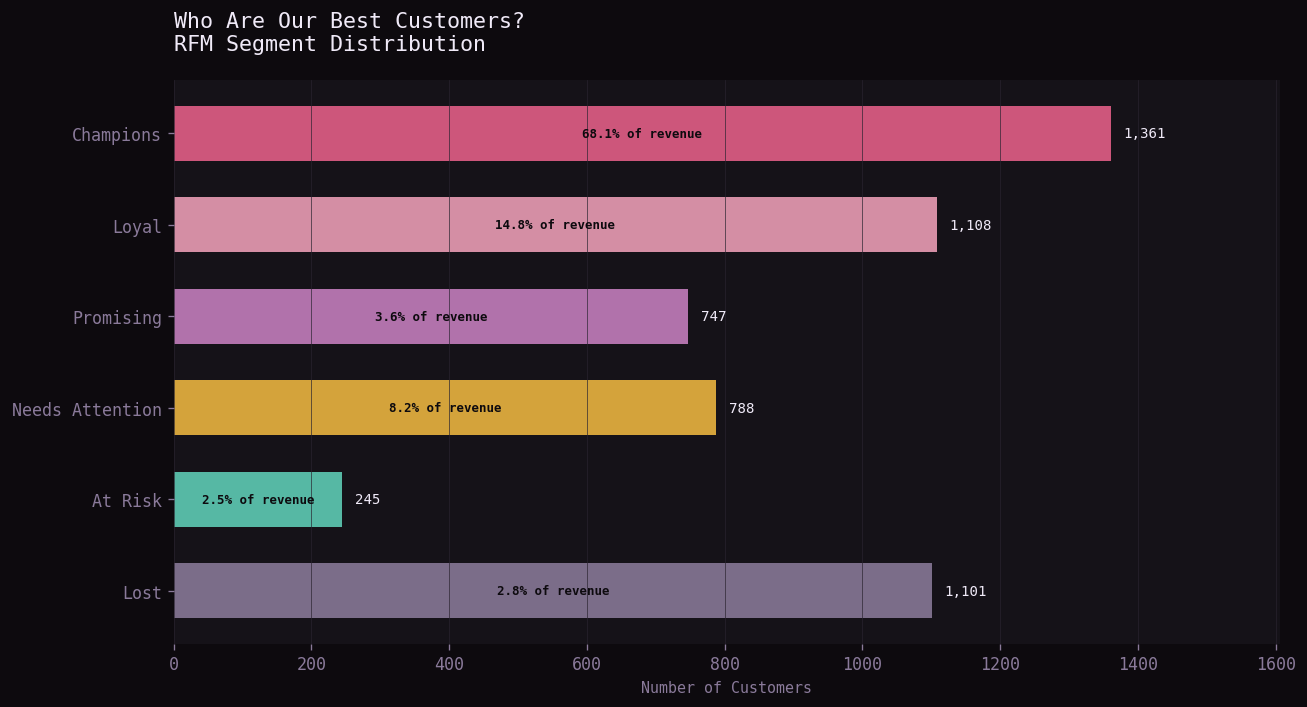

Chart 1 saved.


In [ ]:
# Chart 1: RFM Segment Distribution

segment_order  = ['Champions', 'Loyal', 'Promising',
                  'Needs Attention', 'At Risk', 'Lost']
segment_colors = [PINK, ROSE, MAUVE, AMBER, TEAL, MUTED]

# Build plot dataframe
plot_df = segment_profile.reindex(segment_order).reset_index()

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(plot_df['Segment'], plot_df['Customers'],
               color=segment_colors, alpha=0.88, height=0.6)

# Customer count labels
for bar, count in zip(bars, plot_df['Customers']):
    ax.text(bar.get_width() + 18, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=8.5, color=TEXT)

# Revenue % annotations
for bar, rev_pct in zip(bars, plot_df['% of Revenue']):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'{rev_pct:.1f}% of revenue', va='center', ha='center',
            fontsize=7.5, color=BG, fontweight='bold')

ax.set_title('Who Are Our Best Customers?\nRFM Segment Distribution',
             color=TEXT, fontsize=13, pad=18, loc='left')
ax.set_xlabel('Number of Customers', fontsize=9)
ax.invert_yaxis()
ax.grid(axis='x', linewidth=0.4)
ax.set_xlim(0, plot_df['Customers'].max() * 1.18)

plt.tight_layout()
plt.savefig('chart1_segment_distribution.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 1 saved.")

### Chart 2 — What Does Churn Actually Cost?
**Revenue at Risk by Segment**

Churn becomes real when it has a price tag. This chart breaks total
historical revenue into three categories: active, at-risk and churned
making the financial cost of customer inactivity impossible to ignore.

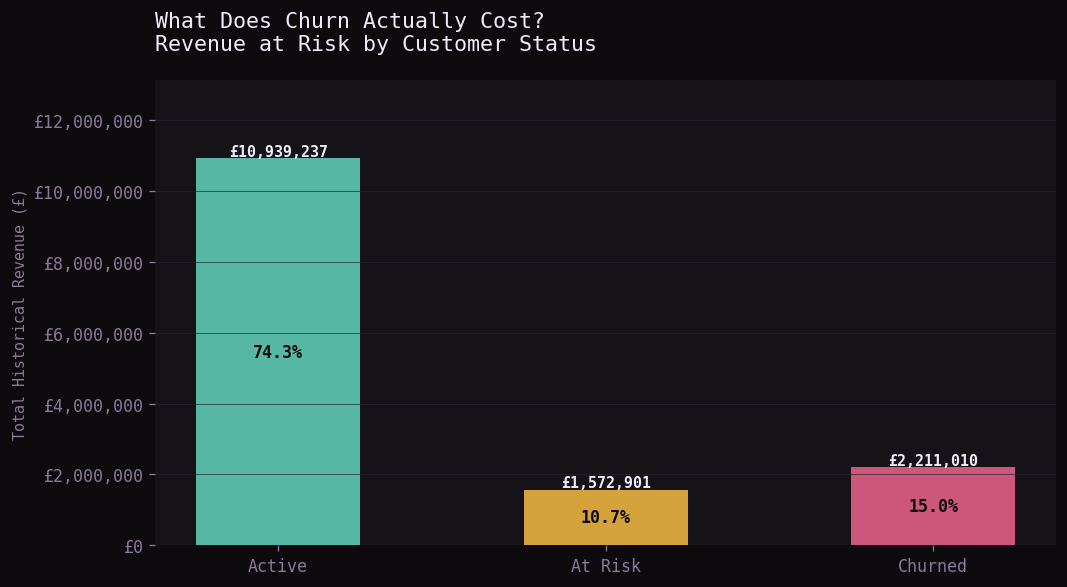

Chart 2 saved.


In [ ]:
# Chart 2: Revenue at Risk by Segment

# Classify each customer into Active / At Risk / Churned
def revenue_status(row):
    if not row['Churned'] and row['Segment'] in ['Champions', 'Loyal', 'Promising']:
        return 'Active'
    elif row['Segment'] in ['Needs Attention', 'At Risk']:
        return 'At Risk'
    else:
        return 'Churned'

rfm['Revenue_Status'] = rfm.apply(revenue_status, axis=1)

status_revenue = rfm.groupby('Revenue_Status')['Monetary'].sum().reindex(
    ['Active', 'At Risk', 'Churned']
)
status_colors = [TEAL, AMBER, PINK]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(status_revenue.index, status_revenue.values,
              color=status_colors, alpha=0.88, width=0.5)

# Value labels
for bar, val in zip(bars, status_revenue.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60000,
            f'£{val:,.0f}', ha='center', fontsize=9, color=TEXT, fontweight='bold')

# % labels inside bars
total_rev = status_revenue.sum()
for bar, val in zip(bars, status_revenue.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{val/total_rev*100:.1f}%', ha='center', va='center',
            fontsize=10, color=BG, fontweight='bold')

ax.set_title('What Does Churn Actually Cost?\nRevenue at Risk by Customer Status',
             color=TEXT, fontsize=13, pad=18, loc='left')
ax.set_ylabel('Total Historical Revenue (£)', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.grid(axis='y', linewidth=0.4)
ax.set_ylim(0, status_revenue.max() * 1.2)

plt.tight_layout()
plt.savefig('chart2_revenue_at_risk.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 2 saved.")

### Chart 3 — How Loyal Are Our Customers Really?
**Repeat Purchase Distribution**

Purchase frequency is the loyalty metric that matters most. This chart
shows how many customers bought once, twice, three times and beyond
revealing the shape of the loyalty curve in this customer base.

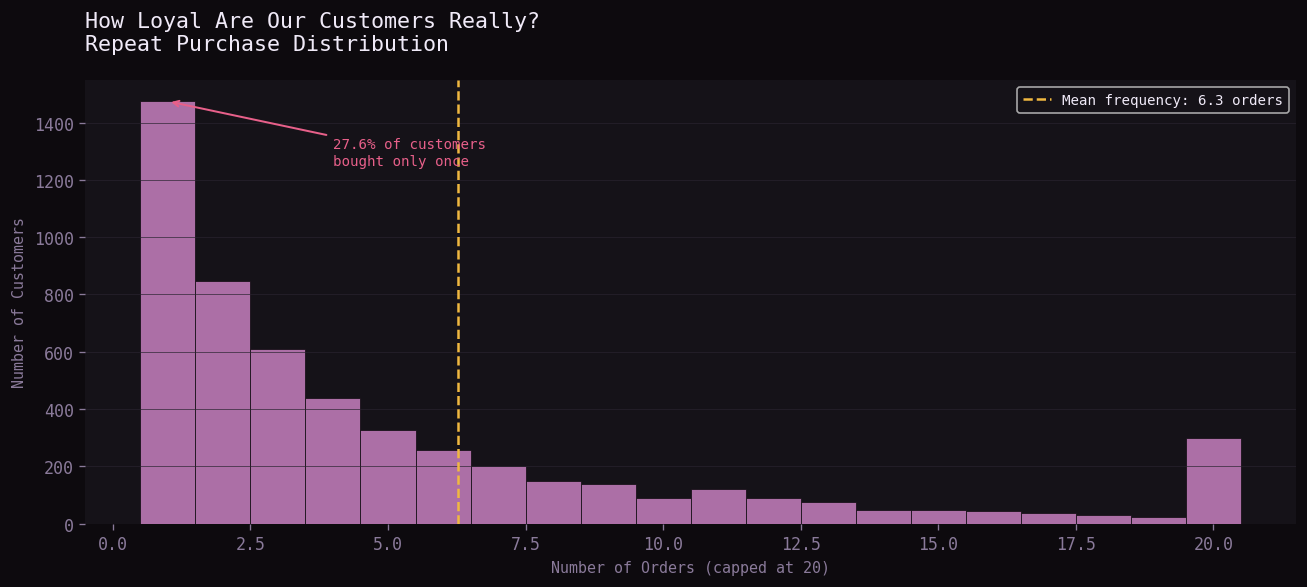

Chart 3 saved.


In [ ]:
# Chart 3: Repeat Purchase Distribution

# Cap at 20 orders for readability — tail is very thin beyond that
freq_capped = rfm['Frequency'].clip(upper=20)
mean_freq   = rfm['Frequency'].mean()
one_time_pct = (rfm['Frequency'] == 1).sum() / len(rfm) * 100

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(freq_capped, bins=range(1, 22), color=MAUVE, alpha=0.85,
        edgecolor=BG, linewidth=0.5, align='left')

# Mean frequency line
ax.axvline(mean_freq, color=AMBER, linewidth=1.5, linestyle='--',
           label=f'Mean frequency: {mean_freq:.1f} orders')

# One-time buyer annotation
one_time_count = (rfm['Frequency'] == 1).sum()
ax.annotate(f'{one_time_pct:.1f}% of customers\nbought only once',
            xy=(1, one_time_count), xytext=(4, one_time_count * 0.85),
            arrowprops=dict(arrowstyle='->', color=PINK, lw=1.2),
            fontsize=8.5, color=PINK)

ax.set_title('How Loyal Are Our Customers Really?\nRepeat Purchase Distribution',
             color=TEXT, fontsize=13, pad=18, loc='left')
ax.set_xlabel('Number of Orders (capped at 20)', fontsize=9)
ax.set_ylabel('Number of Customers', fontsize=9)
ax.legend(facecolor=SURF, labelcolor=TEXT, fontsize=8.5)
ax.grid(axis='y', linewidth=0.4)

plt.tight_layout()
plt.savefig('chart3_repeat_purchase.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 3 saved.")

### Chart 4 — Which Products Drive the Business?
**Revenue Concentration (Pareto Analysis)**

The 80/20 rule states that a small number of products generate the
majority of revenue. This chart proves it in this dataset specifically
showing the top 20 products by revenue with a cumulative percentage line
that makes the concentration visible at a glance.

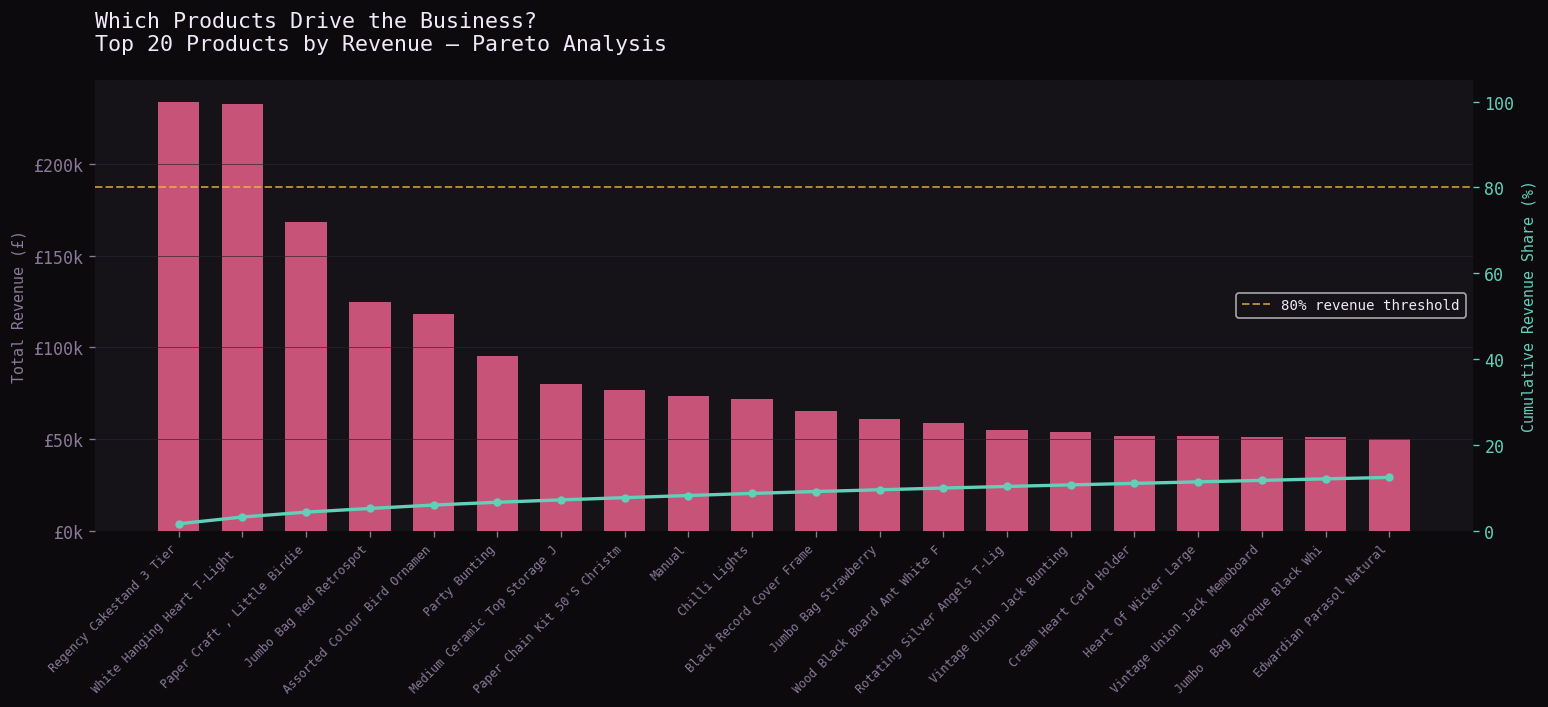

Chart 4 saved.


In [ ]:
# Chart 4: Revenue Concentration — Pareto Chart

top20 = product_revenue.head(20).copy()
top20['Short_Name'] = top20['Description'].str.title().str[:28]

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# Bars — revenue per product
bars = ax1.bar(range(len(top20)), top20['Total_Revenue'],
               color=PINK, alpha=0.85, width=0.65)

# Line — cumulative %
ax2.plot(range(len(top20)), top20['Cumulative_Share'],
         color=TEAL, linewidth=2, marker='o', markersize=4)

# 80% threshold line
ax2.axhline(80, color=AMBER, linewidth=1.2, linestyle='--', alpha=0.7,
            label='80% revenue threshold')

ax1.set_xticks(range(len(top20)))
ax1.set_xticklabels(top20['Short_Name'], rotation=45, ha='right',
                    fontsize=7.2)
ax1.set_ylabel('Total Revenue (£)', fontsize=9)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

ax2.set_ylabel('Cumulative Revenue Share (%)', fontsize=9, color=TEAL)
ax2.tick_params(axis='y', colors=TEAL)
ax2.set_ylim(0, 105)
ax2.legend(facecolor=SURF, labelcolor=TEXT, fontsize=8.5, loc='center right')

ax1.set_title('Which Products Drive the Business?\nTop 20 Products by Revenue — Pareto Analysis',
              color=TEXT, fontsize=13, pad=18, loc='left')
ax1.grid(axis='y', linewidth=0.4)

plt.tight_layout()
plt.savefig('chart4_pareto.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 4 saved.")

### Chart 5 — When Do Customers Leave?
**Recency Distribution by Segment**

Recency is the sharpest predictor of future behaviour. This chart
overlays the recency distributions of all six segments showing
not just where each group sits today, but how separated they are
from the active customer population.

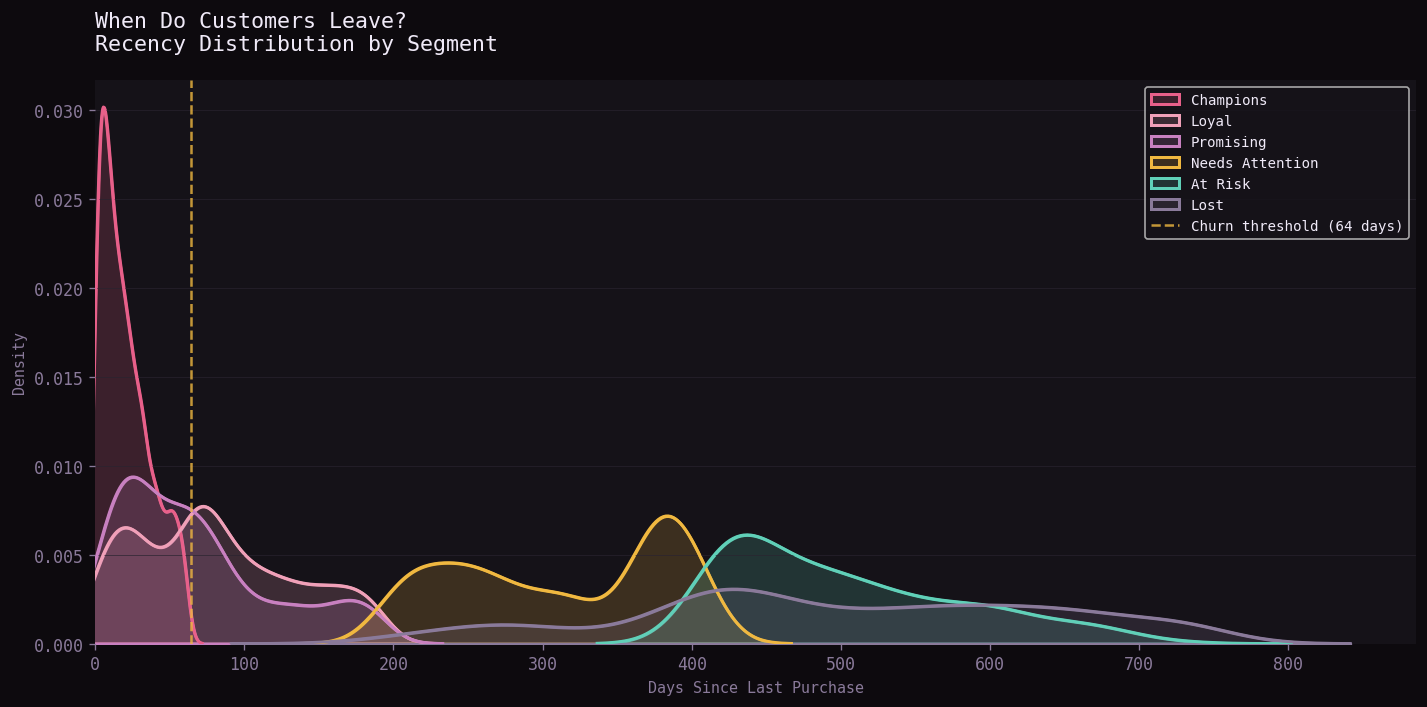

Chart 5 saved.


In [ ]:
#  Chart 5: Recency Distribution by Segment — KDE Plot

seg_colors = {
    'Champions':      PINK,
    'Loyal':          ROSE,
    'Promising':      MAUVE,
    'Needs Attention': AMBER,
    'At Risk':        TEAL,
    'Lost':           MUTED
}

fig, ax = plt.subplots(figsize=(12, 6))

for segment, color in seg_colors.items():
    data = rfm[rfm['Segment'] == segment]['Recency']
    if len(data) > 10:
        sns.kdeplot(data, ax=ax, color=color, fill=True,
                    alpha=0.18, linewidth=1.8, label=segment)
        sns.kdeplot(data, ax=ax, color=color,
                    fill=False, linewidth=1.8)

# Churn threshold line
ax.axvline(churn_threshold, color=AMBER, linewidth=1.5,
           linestyle='--', alpha=0.8,
           label=f'Churn threshold ({churn_threshold} days)')

ax.set_title('When Do Customers Leave?\nRecency Distribution by Segment',
             color=TEXT, fontsize=13, pad=18, loc='left')
ax.set_xlabel('Days Since Last Purchase', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.legend(facecolor=SURF, labelcolor=TEXT, fontsize=8.5,
          framealpha=0.8)
ax.grid(axis='y', linewidth=0.4)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig('chart5_recency_distribution.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 5 saved.")

### Phase 5 Complete — Five Charts Produced

**Charts produced:**
- chart1_segment_distribution.png — RFM segment customer breakdown
- chart2_revenue_at_risk.png — Financial cost of churn by status
- chart3_repeat_purchase.png — Purchase frequency loyalty curve
- chart4_pareto.png — Product revenue concentration (80/20)
- chart5_recency_distribution.png — Customer lifecycle by segment

**Next:** Phase 6 — Insight Brief + HTML One-Pager.

## Insight Brief — E-Commerce Revenue & Churn Analysis
**Prepared by:** Otokini Soberekon · Revenue & Sales Analytics
**Dataset:** UCI Online Retail Dataset · 1,067,371 transactions · Dec 2009 – Dec 2011
**Customer base analysed:** 5,350 unique UK customers · £14,723,147.52 total revenue

---

### THE SITUATION

This analysis examined two years of transactional data from a UK-based
e-commerce retailer. The objective was to identify which customers are
at risk of leaving, where revenue is concentrated and what actions
would have the highest retention impact.

The findings reveal a business with a strong core but significant
and quantifiable leakage at the edges.

---

### FINDING 01 — Churn Is Costing More Than It Appears

58.1% of customers (3,109 out of 5,350) have not purchased in the
last 64 days and are classified as churned.

These customers generated £3,783,910.71 in historical revenue which is
25.7% of all lifetime revenue this business has ever produced.

For every £4 this business has earned, £1 came from a customer
who has since stopped returning.

Critically, the At Risk segment (customers going quiet after a
history of frequent buying) averages 502 days since their last
purchase. This is not early-stage disengagement, this is a
customer base that was once active and has been lost gradually,
without intervention.

---

### FINDING 02 — The Repeat Purchase Foundation Is Strong, But Fragile

72.4% of customers have purchased more than once which is well above the
industry benchmark of 35%. On the surface, this is a strong signal.

However, the 27.6% of customers who purchased only once generated
just £481,109, this is 3.3% of total revenue. The business has successfully
retained its high-value buyers. The risk is concentration: 41.9% of
customers are carrying 74.3% of all revenue. If active customer
behaviour deteriorates, there is limited inactive revenue to absorb
the impact.

The repeat purchase foundation is strong. The vulnerability is in
how narrow it is.

---

### FINDING 03 — Revenue Is Dangerously Concentrated

21.1% of products (1,114 SKUs out of 5,281) generate 80% of all
revenue. The remaining 79% of the catalogue contributes the other 20%.

The top product alone: REGENCY CAKESTAND 3 TIER generated
£234,185.80 individually. The top 10 products account for 8.67%
of total revenue.

This concentration is both an opportunity and a risk. The revenue
critical SKUs are known and can be prioritised. But a supply
disruption, a pricing error, or a delisting on any of the top 20
products would have a measurable and immediate impact on total revenue.

---

### RECOMMENDATION 01 — Launch a Win-Back Campaign for At Risk Customers

The At Risk segment (245 customers, £372,898 in historical revenue)
has a proven purchase history. These are not one-time buyers who
drifted, they are former regulars who have gone quiet.

Priority action: a targeted 30-day re-engagement sequence for At Risk
customers with an M_Score of 3 or above. These customers have both the
history and the spend profile to return. The cost of reactivation is
a fraction of new customer acquisition.

---

### RECOMMENDATION 02 — Protect the Champions Segment Above All Else

Champions represent 25.4% of customers but 68.1% of revenue
£10,028,932 of the £14,723,147 total. There is no retention strategy
more important than keeping this group active.

Priority action: exclusive early access, loyalty recognition and
personalised communication cadence for Champions. Do not treat them
the same as the general customer base. Any reduction in Champions
activity would have an outsized impact on total revenue that no
acquisition campaign could quickly replace.

---

### RECOMMENDATION 03 — Reduce Dependency on Revenue-Concentrated SKUs

The top 20% of products driving 80% of revenue is not a problem to
solve, it is a reality to manage. The risk is in single points of
failure within that top tier.

Priority action: inventory protection, supplier redundancy and bundle
strategy for the top 20 revenue-generating SKUs. Introduce adjacent
products into the high-revenue categories to distribute concentration
risk without disrupting what is already working.

---

*Analysis conducted using Python (pandas, matplotlib, seaborn).*
*Dataset: UCI Online Retail Dataset Version 2 via Kaggle.*
*Methodology: RFM segmentation · Quintile scoring · Pareto analysis*

In [ ]:
# ── Insight Brief — HTML File (matches Project 1 format) ──────────────────────

insight_brief_html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>E-Commerce Revenue & Churn Analysis — Insight Brief</title>
    <link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@400;600;700&family=DM+Sans:wght@300;400;500&display=swap" rel="stylesheet">
    <style>
        :root {
            --pink-deep:  #c9667a;
            --pink-mid:   #e8899a;
            --pink-soft:  #f2b8c2;
            --pink-blush: #fce8ec;
            --pink-wash:  #fef6f7;
            --gold:       #c9a96e;
            --charcoal:   #2c2420;
            --warm-grey:  #6b5f5a;
            --light-grey: #d4ccc9;
            --cream:      #faf7f5;
            --white:      #ffffff;
            --border:     #ecddd9;
        }
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body {
            background-color: var(--cream);
            color: var(--charcoal);
            font-family: 'DM Sans', sans-serif;
            font-weight: 300;
            min-height: 100vh;
            display: flex;
            justify-content: center;
            padding: 48px 20px 64px;
        }
        .page { width: 100%; max-width: 780px; }
        .topbar {
            display: flex;
            justify-content: space-between;
            align-items: center;
            margin-bottom: 48px;
            padding-bottom: 20px;
            border-bottom: 1px solid var(--border);
        }
        .topbar-left {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.18em;
            text-transform: uppercase;
            color: var(--pink-deep);
        }
        .topbar-right {
            font-size: 11px;
            color: var(--warm-grey);
            letter-spacing: 0.05em;
        }
        .hero { margin-bottom: 52px; }
        .hero-eyebrow {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.2em;
            text-transform: uppercase;
            color: var(--pink-deep);
            margin-bottom: 14px;
            display: flex;
            align-items: center;
            gap: 10px;
        }
        .hero-eyebrow::before {
            content: '';
            display: inline-block;
            width: 28px;
            height: 1px;
            background-color: var(--pink-deep);
        }
        .hero h1 {
            font-family: 'Playfair Display', serif;
            font-size: 42px;
            font-weight: 700;
            line-height: 1.15;
            color: var(--charcoal);
            margin-bottom: 18px;
            letter-spacing: -0.01em;
        }
        .hero h1 em { font-style: normal; color: var(--pink-deep); }
        .hero-meta { display: flex; gap: 10px; flex-wrap: wrap; }
        .meta-pill {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.08em;
            padding: 5px 12px;
            border-radius: 20px;
            background-color: var(--pink-blush);
            color: var(--pink-deep);
            border: 1px solid var(--pink-soft);
        }
        .divider {
            width: 100%;
            height: 1px;
            background: linear-gradient(to right, var(--pink-soft), transparent);
            margin: 40px 0;
        }
        .section { margin-bottom: 44px; }
        .section-header {
            display: flex;
            align-items: baseline;
            gap: 12px;
            margin-bottom: 20px;
        }
        .section-num {
            font-family: 'Playfair Display', serif;
            font-size: 13px;
            font-weight: 600;
            color: var(--pink-soft);
            letter-spacing: 0.05em;
        }
        .section-title {
            font-size: 11px;
            font-weight: 500;
            letter-spacing: 0.2em;
            text-transform: uppercase;
            color: var(--warm-grey);
        }
        .situation-text {
            font-size: 15px;
            line-height: 1.85;
            color: var(--charcoal);
            font-weight: 300;
            max-width: 680px;
            padding-left: 20px;
            border-left: 2px solid var(--pink-soft);
        }
        .finding {
            display: grid;
            grid-template-columns: 36px 1fr;
            gap: 0 18px;
            margin-bottom: 18px;
            padding: 20px 24px;
            background-color: var(--white);
            border-radius: 10px;
            border: 1px solid var(--border);
        }
        .finding-num {
            font-family: 'Playfair Display', serif;
            font-size: 28px;
            font-weight: 700;
            color: var(--pink-blush);
            line-height: 1;
            padding-top: 2px;
        }
        .finding-headline {
            font-size: 13.5px;
            font-weight: 500;
            color: var(--charcoal);
            margin-bottom: 6px;
            line-height: 1.4;
        }
        .finding-detail {
            font-size: 13px;
            line-height: 1.75;
            color: var(--warm-grey);
            font-weight: 300;
        }
        .finding-detail strong { color: var(--pink-deep); font-weight: 500; }
        .impact-grid {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 14px;
        }
        .impact-card {
            background-color: var(--white);
            border: 1px solid var(--border);
            border-radius: 10px;
            padding: 22px 18px;
            text-align: center;
        }
        .impact-card.churn   { border-top: 3px solid #e07070; }
        .impact-card.risk    { border-top: 3px solid var(--gold); }
        .impact-card.active  { border-top: 3px solid var(--pink-deep); }
        .impact-value {
            font-family: 'Playfair Display', serif;
            font-size: 26px;
            font-weight: 700;
            margin-bottom: 6px;
            line-height: 1;
        }
        .impact-card.churn  .impact-value { color: #c75555; }
        .impact-card.risk   .impact-value { color: var(--gold); }
        .impact-card.active .impact-value { color: var(--pink-deep); }
        .impact-label {
            font-size: 11px;
            color: var(--warm-grey);
            line-height: 1.5;
        }
        .impact-note {
            margin-top: 14px;
            font-size: 12px;
            color: var(--warm-grey);
            line-height: 1.7;
            font-style: italic;
            padding: 12px 16px;
            background-color: var(--pink-wash);
            border-radius: 8px;
            border: 1px solid var(--pink-blush);
        }
        .recommendation {
            display: grid;
            grid-template-columns: 36px 1fr;
            gap: 0 18px;
            margin-bottom: 16px;
            padding: 22px 24px;
            background-color: var(--white);
            border-radius: 10px;
            border: 1px solid var(--border);
        }
        .rec-num {
            font-family: 'Playfair Display', serif;
            font-size: 28px;
            font-weight: 700;
            color: var(--pink-blush);
            line-height: 1;
            padding-top: 2px;
        }
        .rec-title {
            font-size: 12px;
            font-weight: 500;
            letter-spacing: 0.12em;
            text-transform: uppercase;
            color: var(--pink-deep);
            margin-bottom: 8px;
        }
        .rec-text {
            font-size: 13px;
            line-height: 1.8;
            color: var(--warm-grey);
            font-weight: 300;
        }
        .rec-text strong { color: var(--charcoal); font-weight: 500; }
        .footer {
            margin-top: 52px;
            padding-top: 22px;
            border-top: 1px solid var(--border);
            display: flex;
            justify-content: space-between;
            align-items: center;
            flex-wrap: wrap;
            gap: 12px;
        }
        .footer-left  { font-size: 11px; color: var(--light-grey); }
        .footer-right { font-size: 11px; color: var(--pink-deep); font-weight: 500; }
    </style>
</head>
<body>
<div class="page">

    <div class="topbar">
        <div class="topbar-left">Portfolio Project 02 &nbsp;·&nbsp; E-Commerce Revenue & Churn Analysis</div>
        <div class="topbar-right">Python · Pandas · Matplotlib · Seaborn</div>
    </div>

    <div class="hero">
        <div class="hero-eyebrow">Executive Insight Brief</div>
        <h1>Which Customers Are <em>Quietly Leaving</em><br>— and What Is It Costing?</h1>
        <div class="hero-meta">
            <span class="meta-pill">1,067,371 Transactions</span>
            <span class="meta-pill">5,350 Customers</span>
            <span class="meta-pill">Dec 2009 – Dec 2011</span>
            <span class="meta-pill">RFM Segmentation</span>
        </div>
    </div>

    <!-- SITUATION -->
    <div class="section">
        <div class="section-header">
            <span class="section-num">01</span>
            <span class="section-title">The Situation</span>
        </div>
        <p class="situation-text">
            This analysis examined two years of transactional data from a UK-based
            e-commerce retailer: 1,067,371 transactions across 5,350 unique customers,
            generating £14,723,147.52 in total revenue. The objective was to identify
            which customers are at risk of leaving, where revenue is concentrated,
            and what actions would have the highest retention impact.
            The findings reveal a business with a strong core but significant
            and quantifiable leakage at the edges.
        </p>
    </div>

    <div class="divider"></div>

    <!-- FINDINGS -->
    <div class="section">
        <div class="section-header">
            <span class="section-num">02</span>
            <span class="section-title">Key Findings</span>
        </div>

        <div class="finding">
            <div class="finding-num">1</div>
            <div class="finding-body">
                <div class="finding-headline">58.1% of customers have gone silent and it is costing £3.78M.</div>
                <div class="finding-detail">
                    3,109 of 5,350 customers have not purchased in 64+ days and are classified
                    as churned. These customers generated <strong>£3,783,910.71 which is 25.7% of all
                    lifetime revenue</strong> ever produced. For every £4 this business has earned,
                    £1 came from a customer who has since stopped returning. The At Risk segment
                    averages 502 days of silence. This is not early disengagement, it is a
                    customer base that was once active and has been lost gradually, without intervention.
                </div>
            </div>
        </div>

        <div class="finding">
            <div class="finding-num">2</div>
            <div class="finding-body">
                <div class="finding-headline">25.4% of customers generate 68.1% of all revenue.</div>
                <div class="finding-detail">
                    Champions just 1,361 customers account for <strong>£10,028,932 of the
                    £14,723,147 total</strong>. Their average spend of £7,368 is nearly 4× that
                    of Loyal customers and 19× that of Lost customers. The repeat purchase rate
                    of 72.4% exceeds the 35% industry benchmark but 41.9% of customers are
                    carrying 74.3% of revenue. The loyalty foundation is strong.
                    <strong>The vulnerability is in how narrow it is.</strong>
                </div>
            </div>
        </div>

        <div class="finding">
            <div class="finding-num">3</div>
            <div class="finding-body">
                <div class="finding-headline">21.1% of products run 80% of the business.</div>
                <div class="finding-detail">
                    1,114 SKUs out of 5,281 generate 80% of all revenue. The remaining 79% of
                    the catalogue contributes just 20%. The top product alone
                    <strong>REGENCY CAKESTAND 3 TIER generated £234,185</strong> individually.
                    This concentration is both an opportunity and a risk: the revenue-critical
                    SKUs are known and can be prioritised, but a supply disruption on any top-20
                    product has an immediate, measurable impact on total revenue.
                </div>
            </div>
        </div>
    </div>

    <div class="divider"></div>

    <!-- REVENUE IMPACT -->
    <div class="section">
        <div class="section-header">
            <span class="section-num">03</span>
            <span class="section-title">Revenue Impact</span>
        </div>
        <div class="impact-grid">
            <div class="impact-card churn">
                <div class="impact-value">£3.78M</div>
                <div class="impact-label">Revenue from<br>churned customers</div>
            </div>
            <div class="impact-card risk">
                <div class="impact-value">£1.57M</div>
                <div class="impact-label">Revenue from At Risk<br>& Needs Attention</div>
            </div>
            <div class="impact-card active">
                <div class="impact-value">£10.93M</div>
                <div class="impact-label">Revenue from<br>active customers</div>
            </div>
        </div>
        <p class="impact-note">
            Active customers (41.9% of the base) are carrying 74.3% of all revenue.
            The churned segment represents 25.7% of lifetime revenue now sitting
            in an inactive customer base recoverable through targeted retention,
            not new acquisition spend.
        </p>
    </div>

    <div class="divider"></div>

    <!-- RECOMMENDATIONS -->
    <div class="section">
        <div class="section-header">
            <span class="section-num">04</span>
            <span class="section-title">Recommendations</span>
        </div>

        <div class="recommendation">
            <div class="rec-num">1</div>
            <div class="rec-body">
                <div class="rec-title">Launch a 30-Day Win-Back Campaign for At Risk Customers</div>
                <div class="rec-text">
                    The At Risk segment (245 customers, <strong>£372,898 in historical revenue</strong>)
                    has a proven purchase history, these are former regulars who have gone quiet,
                    not one-time buyers who drifted. <strong>Priority: customers with M_Score ≥ 3</strong>,
                    who have the spend profile to return. A targeted re-engagement sequence costs
                    a fraction of new customer acquisition and targets buyers who already know and
                    trust the brand.
                </div>
            </div>
        </div>

        <div class="recommendation">
            <div class="rec-num">2</div>
            <div class="rec-body">
                <div class="rec-title">Protect the Champions Segment Above All Else</div>
                <div class="rec-text">
                    Champions generate <strong>£10,028,932 — 68.1% of total revenue</strong>.
                    No acquisition campaign can quickly replace a drop in Champions activity.
                    <strong>Exclusive access, loyalty recognition, and a dedicated communication
                    cadence</strong> are non-negotiable investments for this group. They should
                    never be treated as part of the general customer base, their behaviour
                    is the business.
                </div>
            </div>
        </div>

        <div class="recommendation">
            <div class="rec-num">3</div>
            <div class="rec-body">
                <div class="rec-title">Reduce Dependency on Revenue-Concentrated SKUs</div>
                <div class="rec-text">
                    The top 20% of products driving 80% of revenue is a reality to manage,
                    not a problem to solve. The risk is in single points of failure.
                    <strong>Inventory protection, supplier redundancy and bundle strategy
                    for the top 20 SKUs</strong> should be treated as a risk management priority.
                    Introducing adjacent products into high-revenue categories distributes
                    concentration without disrupting what is already working.
                </div>
            </div>
        </div>
    </div>

    <div class="footer">
        <div class="footer-left">Analysis · UCI Online Retail Dataset v2 · 1,067,371 transactions · Python · Pandas · Matplotlib · Seaborn</div>
        <div class="footer-right">github.com/otokinisoberekon06-hub/rfm-churn-analysis</div>
    </div>

</div>
</body>
</html>"""

with open('insight_brief.html', 'w') as f:
    f.write(insight_brief_html)

print("Insight brief saved as insight_brief.html")

from google.colab import files
files.download('insight_brief.html')

In [ ]:
# Export Charts as Base64 for HTML Embedding
import base64

def img_to_base64(filepath):
    with open(filepath, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

chart1 = img_to_base64('chart1_segment_distribution.png')
chart2 = img_to_base64('chart2_revenue_at_risk.png')
chart4 = img_to_base64('chart4_pareto.png')

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>E-Commerce Revenue & Churn Analysis — Otokini Soberekon</title>
<link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,400;0,700;0,900;1,400&family=Epilogue:wght@300;400;500;600&family=Courier+Prime:wght@400;700&display=swap" rel="stylesheet">
<style>
  :root {{
    --bg:    #0d0a0e;
    --surf:  #151218;
    --surf2: #1c1820;
    --bord:  #2a2430;
    --bord2: #362e3e;
    --text:  #f0eaf8;
    --muted: #8a7a9a;
    --dim:   #b0a0c0;
    --pink:  #e8608a;
    --rose:  #f0a0b8;
    --mauve: #c880c0;
    --teal:  #60d0b8;
    --amber: #f0b840;
  }}

  * {{ margin: 0; padding: 0; box-sizing: border-box; }}

  body {{
    background: var(--bg);
    color: var(--text);
    font-family: 'Epilogue', sans-serif;
    font-weight: 300;
    line-height: 1.7;
  }}

  /* ── HEADER ── */
  header {{
    padding: 4rem 2rem 3.5rem;
    border-bottom: 1px solid var(--bord);
    position: relative;
    overflow: hidden;
  }}
  header::before {{
    content: '';
    position: absolute;
    inset: 0;
    background:
      radial-gradient(ellipse 60% 70% at 85% 30%, rgba(232,96,138,0.08) 0%, transparent 55%),
      radial-gradient(ellipse 40% 50% at 15% 70%, rgba(200,128,192,0.05) 0%, transparent 50%);
  }}
  header::after {{
    content: '';
    position: absolute;
    bottom: 0; left: 0; right: 0;
    height: 1px;
    background: linear-gradient(90deg, transparent, var(--pink), var(--mauve), transparent);
  }}
  .h-inner {{ max-width: 960px; margin: 0 auto; position: relative; }}

  .chips {{
    display: flex; gap: 0.6rem; flex-wrap: wrap;
    margin-bottom: 1.5rem;
  }}
  .chip {{
    font-family: 'Courier Prime', monospace;
    font-size: 0.58rem;
    letter-spacing: 0.15em;
    text-transform: uppercase;
    padding: 0.25rem 0.65rem;
    border-radius: 2px;
  }}
  .chip-pink  {{ background: rgba(232,96,138,0.1);  color: var(--pink);  border: 1px solid rgba(232,96,138,0.25); }}
  .chip-teal  {{ background: rgba(96,208,184,0.08); color: var(--teal);  border: 1px solid rgba(96,208,184,0.2);  }}
  .chip-mauve {{ background: rgba(200,128,192,0.1); color: var(--mauve); border: 1px solid rgba(200,128,192,0.2); }}
  .chip-muted {{ background: var(--surf2); color: var(--muted); border: 1px solid var(--bord); }}

  header h1 {{
    font-family: 'Playfair Display', serif;
    font-size: clamp(2rem, 5vw, 3.4rem);
    font-weight: 900;
    line-height: 1.08;
    letter-spacing: -0.02em;
    margin-bottom: 1rem;
  }}
  header h1 em {{ color: var(--pink); font-style: italic; }}

  .h-sub {{
    font-size: 0.88rem;
    color: var(--muted);
    max-width: 560px;
    line-height: 1.8;
    margin-bottom: 2rem;
  }}

  .h-meta {{
    display: flex;
    gap: 2rem;
    flex-wrap: wrap;
  }}
  .h-meta-item {{
    font-family: 'Courier Prime', monospace;
    font-size: 0.7rem;
    color: var(--muted);
    letter-spacing: 0.05em;
  }}
  .h-meta-item strong {{
    display: block;
    color: var(--text);
    font-size: 0.82rem;
    margin-bottom: 0.1rem;
  }}

  /* ── PAGE ── */
  .page {{ max-width: 960px; margin: 0 auto; padding: 0 1.5rem 5rem; }}

  /* ── STAT BLOCKS ── */
  .stats {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
    gap: 1px;
    margin: 3rem 0;
    border: 1px solid var(--bord);
    border-radius: 4px;
    overflow: hidden;
  }}
  .stat {{
    background: var(--surf);
    padding: 1.5rem 1.25rem;
    position: relative;
  }}
  .stat::before {{
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 2px;
  }}
  .stat.pink::before  {{ background: var(--pink);  }}
  .stat.teal::before  {{ background: var(--teal);  }}
  .stat.amber::before {{ background: var(--amber); }}
  .stat.mauve::before {{ background: var(--mauve); }}

  .stat-label {{
    font-family: 'Courier Prime', monospace;
    font-size: 0.58rem;
    letter-spacing: 0.15em;
    text-transform: uppercase;
    color: var(--muted);
    margin-bottom: 0.5rem;
  }}
  .stat-value {{
    font-family: 'Playfair Display', serif;
    font-size: clamp(1.6rem, 3vw, 2.2rem);
    font-weight: 900;
    line-height: 1;
    margin-bottom: 0.4rem;
  }}
  .stat.pink  .stat-value {{ color: var(--pink);  }}
  .stat.teal  .stat-value {{ color: var(--teal);  }}
  .stat.amber .stat-value {{ color: var(--amber); }}
  .stat.mauve .stat-value {{ color: var(--mauve); }}
  .stat-note {{
    font-size: 0.75rem;
    color: var(--muted);
    line-height: 1.5;
  }}

  /* ── SECTION HEADERS ── */
  .section-hd {{
    margin: 3.5rem 0 1.5rem;
    padding-bottom: 0.75rem;
    border-bottom: 1px solid var(--bord);
  }}
  .section-tag {{
    font-family: 'Courier Prime', monospace;
    font-size: 0.58rem;
    letter-spacing: 0.18em;
    text-transform: uppercase;
    color: var(--pink);
    margin-bottom: 0.4rem;
  }}
  .section-hd h2 {{
    font-family: 'Playfair Display', serif;
    font-size: clamp(1.2rem, 2.5vw, 1.6rem);
    font-weight: 700;
    line-height: 1.2;
  }}

  /* ── CHARTS ── */
  .chart-block {{
    margin-bottom: 3rem;
    border: 1px solid var(--bord);
    border-radius: 4px;
    overflow: hidden;
  }}
  .chart-header {{
    background: var(--surf);
    padding: 1rem 1.25rem;
    border-bottom: 1px solid var(--bord);
  }}
  .chart-q {{
    font-family: 'Courier Prime', monospace;
    font-size: 0.58rem;
    letter-spacing: 0.15em;
    text-transform: uppercase;
    color: var(--pink);
    margin-bottom: 0.2rem;
  }}
  .chart-header h3 {{
    font-family: 'Playfair Display', serif;
    font-size: 1.05rem;
    font-weight: 700;
  }}
  .chart-header p {{
    font-size: 0.78rem;
    color: var(--muted);
    margin-top: 0.3rem;
    line-height: 1.6;
  }}
  .chart-img {{
    background: var(--bg);
    padding: 1rem;
  }}
  .chart-img img {{
    width: 100%;
    display: block;
    border-radius: 2px;
  }}

  /* ── FINDINGS ── */
  .findings {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
    gap: 1px;
    margin-top: 1rem;
    border: 1px solid var(--bord);
    border-radius: 4px;
    overflow: hidden;
  }}
  .finding {{
    background: var(--surf);
    padding: 1.5rem 1.25rem;
  }}
  .finding-num {{
    font-family: 'Courier Prime', monospace;
    font-size: 0.6rem;
    letter-spacing: 0.15em;
    color: var(--pink);
    margin-bottom: 0.5rem;
  }}
  .finding h4 {{
    font-family: 'Playfair Display', serif;
    font-size: 0.98rem;
    font-weight: 700;
    margin-bottom: 0.6rem;
    line-height: 1.3;
  }}
  .finding p {{
    font-size: 0.78rem;
    color: var(--dim);
    line-height: 1.7;
  }}
  .finding strong {{ color: var(--text); }}

  /* ── RECOMMENDATIONS ── */
  .recs {{ margin-top: 1rem; }}
  .rec {{
    display: flex;
    gap: 1.25rem;
    padding: 1.25rem;
    border: 1px solid var(--bord);
    border-radius: 4px;
    margin-bottom: 1px;
    background: var(--surf);
  }}
  .rec-num {{
    font-family: 'Playfair Display', serif;
    font-size: 2rem;
    font-weight: 900;
    color: var(--pink);
    opacity: 0.3;
    line-height: 1;
    flex-shrink: 0;
    width: 2rem;
    margin-top: 0.1rem;
  }}
  .rec-body h4 {{
    font-family: 'Playfair Display', serif;
    font-size: 0.98rem;
    font-weight: 700;
    margin-bottom: 0.4rem;
  }}
  .rec-body p {{
    font-size: 0.78rem;
    color: var(--dim);
    line-height: 1.7;
  }}
  .rec-body strong {{ color: var(--text); }}

  /* ── FOOTER ── */
  footer {{
    border-top: 1px solid var(--bord);
    padding: 2rem 1.5rem;
    text-align: center;
  }}
  .footer-inner {{ max-width: 960px; margin: 0 auto; }}
  footer p {{
    font-family: 'Courier Prime', monospace;
    font-size: 0.65rem;
    letter-spacing: 0.08em;
    color: var(--muted);
    line-height: 1.9;
  }}
  footer strong {{ color: var(--dim); }}
</style>
</head>
<body>

<header>
  <div class="h-inner">
    <div class="chips">
      <span class="chip chip-pink">E-Commerce Analytics</span>
      <span class="chip chip-teal">RFM Segmentation</span>
      <span class="chip chip-mauve">Churn Analysis</span>
      <span class="chip chip-muted">Python · Pandas · Matplotlib</span>
    </div>
    <h1>E-Commerce Revenue<br>&amp; <em>Churn Analysis</em></h1>
    <p class="h-sub">
      A full customer segmentation and retention intelligence study
      on two years of UK e-commerce transaction data — identifying
      where revenue is at risk and what actions would recover it.
    </p>
    <div class="h-meta">
      <div class="h-meta-item"><strong>Otokini Soberekon</strong>Revenue & Sales Analytics</div>
      <div class="h-meta-item"><strong>1,067,371</strong>Transactions analysed</div>
      <div class="h-meta-item"><strong>5,350</strong>Unique customers</div>
      <div class="h-meta-item"><strong>Dec 2009 – Dec 2011</strong>Date range</div>
      <div class="h-meta-item"><strong>£14,723,147.52</strong>Total revenue</div>
    </div>
  </div>
</header>

<div class="page">

  <!-- STAT BLOCKS -->
  <div class="stats">
    <div class="stat pink">
      <div class="stat-label">Revenue at Risk</div>
      <div class="stat-value">£3.78M</div>
      <div class="stat-note">Generated by churned customers — 25.7% of all lifetime revenue</div>
    </div>
    <div class="stat teal">
      <div class="stat-label">Churn Rate</div>
      <div class="stat-value">58.1%</div>
      <div class="stat-note">3,109 of 5,350 customers inactive for 64+ days</div>
    </div>
    <div class="stat amber">
      <div class="stat-label">Revenue Concentration</div>
      <div class="stat-value">21.1%</div>
      <div class="stat-note">of SKUs drive 80% of all revenue — 1,114 of 5,281 products</div>
    </div>
    <div class="stat mauve">
      <div class="stat-label">Repeat Purchase Rate</div>
      <div class="stat-value">72.4%</div>
      <div class="stat-note">vs 35% industry benchmark — strong loyalty foundation</div>
    </div>
  </div>

  <!-- CHARTS -->
  <div class="section-hd">
    <div class="section-tag">Analysis · Charts</div>
    <h2>The Data, Visualised</h2>
  </div>

  <div class="chart-block">
    <div class="chart-header">
      <div class="chart-q">Chart 1 · Segmentation</div>
      <h3>Who Are Our Best Customers? — RFM Segment Distribution</h3>
      <p>Champions (25.4% of customers) generate 68.1% of all revenue.
         The bottom three segments account for 39.9% of the customer base
         but only 13.5% of revenue.</p>
    </div>
    <div class="chart-img">
      <img src="data:image/png;base64,{chart1}" alt="RFM Segment Distribution">
    </div>
  </div>

  <div class="chart-block">
    <div class="chart-header">
      <div class="chart-q">Chart 2 · Churn Cost</div>
      <h3>What Does Churn Actually Cost? — Revenue at Risk by Status</h3>
      <p>£3,783,910 in historical revenue sits in an inactive customer base.
         Active customers (41.9% of the base) are carrying 74.3% of all revenue.</p>
    </div>
    <div class="chart-img">
      <img src="data:image/png;base64,{chart2}" alt="Revenue at Risk">
    </div>
  </div>

  <div class="chart-block">
    <div class="chart-header">
      <div class="chart-q">Chart 4 · Product Concentration</div>
      <h3>Which Products Drive the Business? — Pareto Analysis</h3>
      <p>The 80/20 rule proven in this dataset: 1,114 SKUs generate 80%
         of revenue. The top product alone — REGENCY CAKESTAND 3 TIER —
         contributed £234,185 individually.</p>
    </div>
    <div class="chart-img">
      <img src="data:image/png;base64,{chart4}" alt="Pareto Analysis">
    </div>
  </div>

  <!-- FINDINGS -->
  <div class="section-hd">
    <div class="section-tag">Insight Brief · Findings</div>
    <h2>3 Key Findings</h2>
  </div>

  <div class="findings">
    <div class="finding">
      <div class="finding-num">FINDING 01</div>
      <h4>Churn Is Costing More Than It Appears</h4>
      <p><strong>58.1% of customers</strong> have not purchased in 64+ days.
         These churned customers represent <strong>£3,783,910 —
         25.7% of all lifetime revenue</strong> ever generated.
         For every £4 earned, £1 came from a customer who has
         since stopped returning.</p>
    </div>
    <div class="finding">
      <div class="finding-num">FINDING 02</div>
      <h4>Strong Repeat Rate, Narrow Revenue Base</h4>
      <p>A <strong>72.4% repeat purchase rate</strong> exceeds the 35%
         industry benchmark — but <strong>41.9% of customers carry
         74.3% of revenue</strong>. The loyalty foundation is strong;
         the concentration creates fragility.</p>
    </div>
    <div class="finding">
      <div class="finding-num">FINDING 03</div>
      <h4>Revenue Is Dangerously Concentrated</h4>
      <p><strong>21.1% of products</strong> generate 80% of all revenue.
         The top product alone contributes <strong>£234,185</strong>.
         A supply disruption on any top-20 SKU has an immediate,
         measurable revenue impact.</p>
    </div>
  </div>

  <!-- RECOMMENDATIONS -->
  <div class="section-hd">
    <div class="section-tag">Insight Brief · Action</div>
    <h2>3 Specific Recommendations</h2>
  </div>

  <div class="recs">
    <div class="rec">
      <div class="rec-num">01</div>
      <div class="rec-body">
        <h4>Launch a 30-Day Win-Back Campaign for At Risk Customers</h4>
        <p>The At Risk segment (245 customers, <strong>£372,898 in historical revenue</strong>)
           has a proven purchase history. Target those with M_Score ≥ 3.
           Reactivation cost is a fraction of new customer acquisition —
           and these customers already know the brand.</p>
      </div>
    </div>
    <div class="rec">
      <div class="rec-num">02</div>
      <div class="rec-body">
        <h4>Protect the Champions Segment Above All Else</h4>
        <p>Champions generate <strong>£10,028,932 — 68.1% of total revenue</strong>.
           No acquisition campaign can quickly replace a drop in Champions activity.
           Exclusive access, loyalty recognition, and a dedicated communication
           cadence are non-negotiable investments.</p>
      </div>
    </div>
    <div class="rec">
      <div class="rec-num">03</div>
      <div class="rec-body">
        <h4>Reduce Dependency on Revenue-Concentrated SKUs</h4>
        <p>Inventory protection and supplier redundancy on the
           <strong>top 20 revenue-generating SKUs</strong> is a risk management
           priority. Introduce adjacent products into high-revenue categories
           to distribute concentration without disrupting what is working.</p>
      </div>
    </div>
  </div>

</div>

<footer>
  <div class="footer-inner">
    <p>
      <strong>Otokini Soberekon</strong> · Revenue & Sales Analytics · SaaS & E-Commerce<br>
      Analysis conducted in Python using pandas, matplotlib, and seaborn.<br>
      Dataset: UCI Online Retail Dataset Version 2 · RFM Segmentation · Pareto Analysis · Churn Modelling
    </p>
  </div>
</footer>

</body>
</html>"""

with open('rfm_churn_analysis.html', 'w') as f:
    f.write(html)

print("HTML showcase page saved as index.html")
print("Download it from the Colab files panel on the left.")

from google.colab import files
files.download('rfm_churn_analysis.html')

HTML showcase page saved as index.html
Download it from the Colab files panel on the left.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>